In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
REPO_ROOT = Path.home() / "EASM"
PROCESSED_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs" / "som_u850"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# =========================================================
# 0) input paths
# =========================================================
som_csv = OUTPUT_DIR / "som_daily_assignment.csv"
hgt_file = PROCESSED_DIR / "hgt_z850_jja_1982_2025.nc"
out_nc = OUTPUT_DIR / "hgt850_anom_node_composites.nc"
out_fig = OUTPUT_DIR / "hgt850_anom_node_composites_sig2.png"

hgt_varname = "hgt"
extent = [0, 240, -10, 60]
nodes_all = np.arange(1, 10)

In [4]:
# =========================================================
# 1) SOM daily assignments
# =========================================================
df = pd.read_csv(som_csv)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df[df["node"].between(1, 9)].copy()
df = df.sort_values("date").drop_duplicates(subset="date")

In [5]:
# =========================================================
# 2) hgt data
# =========================================================
ds = xr.open_dataset(hgt_file)
hgt = ds[hgt_varname]

rename_dict = {}
if "latitude" in hgt.dims:
    rename_dict["latitude"] = "lat"
if "longitude" in hgt.dims:
    rename_dict["longitude"] = "lon"
if rename_dict:
    hgt = hgt.rename(rename_dict)

hgt = hgt.squeeze(drop=True)
hgt = hgt.assign_coords(time=pd.to_datetime(hgt["time"].values).normalize())
hgt = hgt.transpose("time", "lat", "lon")

if hgt["lat"].values[0] > hgt["lat"].values[-1]:
    hgt = hgt.sortby("lat")
if hgt["lon"].values[0] > hgt["lon"].values[-1]:
    hgt = hgt.sortby("lon")

hgt = hgt.sel(
    lon=slice(extent[0], extent[1]),
    lat=slice(extent[2], extent[3]),
)

In [6]:
# =========================================================
# 3) Daily anomaly
# =========================================================
clim = hgt.groupby("time.dayofyear").mean("time")
hgt_anom = hgt.groupby("time.dayofyear") - clim

In [7]:
# =========================================================
# 4) Common dates
# =========================================================
common_time = np.intersect1d(hgt_anom["time"].values, df["date"].values)

print("len(hgt_anom time) =", hgt_anom.sizes["time"])
print("len(df date)        =", len(df))
print("len(common_time)    =", len(common_time))

if len(common_time) == 0:
    raise ValueError("No common dates were found between the SOM CSV and the hgt dataset.")

hgt_sel = hgt_anom.sel(time=common_time)

node_map = (
    df.set_index("date")["node"]
      .reindex(pd.to_datetime(common_time))
)

valid = ~node_map.isna().to_numpy()
hgt_sel = hgt_sel.isel(time=valid)
node_vals = node_map.to_numpy()[valid].astype(int)

print("len(hgt_sel time) =", hgt_sel.sizes["time"])
print("len(node_vals)     =", len(node_vals))

if hgt_sel.sizes["time"] == 0:
    raise ValueError("hgt_sel has zero time samples after aligning dates.")

len(hgt_anom time) = 4048
len(df date)        = 4048
len(common_time)    = 4048
len(hgt_sel time) = 4048
len(node_vals)     = 4048


In [8]:
# =========================================================
# 5) Node coordinate
# =========================================================
hgt_sel = hgt_sel.assign_coords(node=("time", node_vals))

In [9]:
# =========================================================
# 6) Node composites / std / n / se
# =========================================================
comp = hgt_sel.groupby("node").mean("time")
std = hgt_sel.groupby("node").std("time")
n = hgt_sel.groupby("node").count("time")

comp = comp.reindex(node=nodes_all)
std = std.reindex(node=nodes_all)
n = n.reindex(node=nodes_all)

se = std / np.sqrt(n)
sig2 = (np.abs(comp) >= 2.0 * se).fillna(False)

xr.Dataset(
    {
        "hgt_anom_comp": comp,
        "hgt_anom_std": std,
        "hgt_anom_n": n,
        "hgt_anom_se": se,
        "hgt_anom_sig2": sig2.astype(np.int8),
        "hgt_climatology": clim,
    }
).to_netcdf(out_nc)

print(comp)
print(n)



<xarray.DataArray 'hgt' (node: 9, lat: 29, lon: 97)> Size: 101kB
array([[[  1.6229992 ,   1.7484547 ,   1.8778017 , ...,  -1.1109369 ,
          -1.1815257 ,  -1.270765  ],
        [  1.6929919 ,   1.7258204 ,   1.720002  , ...,  -1.3987257 ,
          -1.4668331 ,  -1.5089709 ],
        [  1.6476144 ,   1.6197184 ,   1.5653381 , ...,  -1.6230347 ,
          -1.6993115 ,  -1.7270676 ],
        ...,
        [  2.0057485 ,   2.8653252 ,   3.7638257 , ...,   0.7062335 ,
           0.3782889 ,  -0.04537997],
        [  2.3011925 ,   3.088917  ,   3.9822993 , ...,  -2.139571  ,
          -2.8199446 ,  -3.429887  ],
        [  2.7873154 ,   3.6001487 ,   4.4127545 , ...,  -5.0017705 ,
          -5.6421175 ,  -6.125356  ]],

       [[  0.37295675,   0.45544213,   0.5252759 , ...,  -1.5524006 ,
          -1.5377452 ,  -1.4753942 ],
        [  0.41289482,   0.43232718,   0.39948   , ...,  -1.2852056 ,
          -1.3608437 ,  -1.282508  ],
        [  0.4251712 ,   0.39443585,   0.3671416 , ..., 

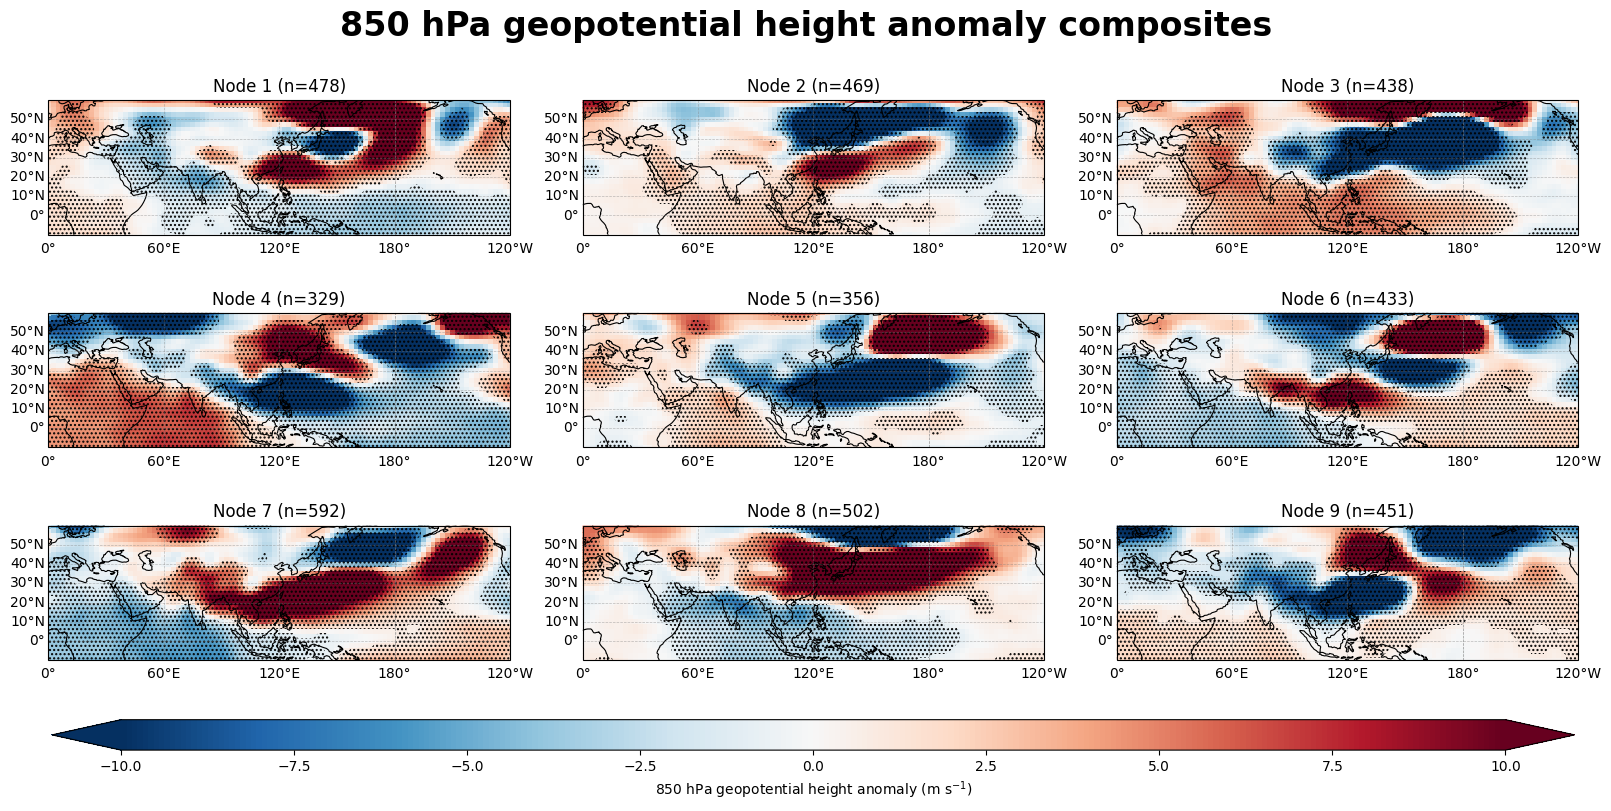

In [10]:
# =========================================================
# 7) Plot
# =========================================================
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    3, 3, figsize=(16, 8), layout="constrained", subplot_kw={"projection": proj}
)

pcm = None

for i, ax in enumerate(axes.flat, start=1):
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    da = comp.sel(node=i).squeeze(drop=True)
    mask = sig2.sel(node=i).squeeze(drop=True)
    node_n = (
        int(np.nanmax(n.sel(node=i).values))
        if np.isfinite(n.sel(node=i).values).any()
        else 0
    )

    if np.isfinite(da.values).any():
        pcm = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            cmap="RdBu_r",
            vmin=-10,
            vmax=10,
            extend="both",
        )

        ax.contourf(
            da["lon"].values,
            da["lat"].values,
            mask.astype(int).values,
            levels=[0.5, 1.5],
            hatches=["...."],
            colors="none",
            transform=ccrs.PlateCarree(),
        )

    ax.coastlines(linewidth=0.8)
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"Node {i} (n={node_n})")

if pcm is not None:
    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
        aspect=50,
        extend="both",
    )
    cbar.set_label("850 hPa geopotential height anomaly (m s$^{-1}$)")

fig.suptitle("850 hPa geopotential height anomaly composites", fontsize=24, fontweight="bold")

plt.savefig(out_fig, dpi=144, bbox_inches="tight")
plt.show()
